https://www.kaggle.com/datasets/mssmartypants/rice-type-classification



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df= pd.read_csv('rice.csv')
df.head()


,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [ ]:
print(df.isnull().sum())

id                 0
Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Perimeter          0
Roundness          0
AspectRation       0
Class              0
dtype: int64


In [ ]:
df.shape

(18185, 12)

In [ ]:
# Take out ID and class
features = [col for col in df.columns if col not in ['id', 'Class']]

#Prints the list so we know what we are using
print('Number of features:', len(features))   # Expected: 10
print('Feature names:', features)

print() #Adds a space between feature names and label distribution

#Count each class. 0= Gonen, 1=Jasmine
print('Label distribution (Class):')
print(df['Class'].value_counts().sort_index())

Number of features: 10
Feature names: ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter', 'Roundness', 'AspectRation']

Label distribution (Class):
Class
0    8200
1    9985
Name: count, dtype: int64


In [ ]:
#Extract only the feature columns
raw_features = df[features]

#finding mean and STD and apply the transformation
x = StandardScaler().fit_transform(raw_features)

print('Normalized data stats:')
print('  Mean : {:.6f}  (should be ~0)'.format(np.mean(x)))
print('  Std  : {:.6f}  (should be ~1)'.format(np.std(x)))
print('  Shape:', x.shape)

Normalized data stats:
  Mean : -0.000000  (should be ~0)
  Std  : 1.000000  (should be ~1)
  Shape: (18185, 10)


In [ ]:

#finds the directions in the data along which the data varies the most
pca = PCA(n_components=2)
principal_components = pca.fit_transform(x)

print('PCA output shape:', principal_components.shape)

pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2'])

print()
print('First 5 rows of PCA result:')
print(pca_df.head())

PCA output shape: (18185, 2)

First 5 rows of PCA result:
        PC1        PC2
0 -0.354083  -8.442447
1 -2.854920 -11.013745
2 -2.482805 -11.056600
3 -2.493232 -10.949386
4 -1.581389  -9.952350


In [ ]:
#Tells how much information each PC keeps
pc1_var, pc2_var = pca.explained_variance_ratio_

print('Explained variance per principal component:')
print('  PC1 : {:.1%}'.format(pc1_var))
print('  PC2 : {:.1%}'.format(pc2_var))
print('  ──────────────────────────────────────────────')
print('  Total: {:.1%}'.format(pc1_var + pc2_var))

Explained variance per principal component:
  PC1 : 63.8%
  PC2 : 26.1%
  ──────────────────────────────────────────────
  Total: 89.9%


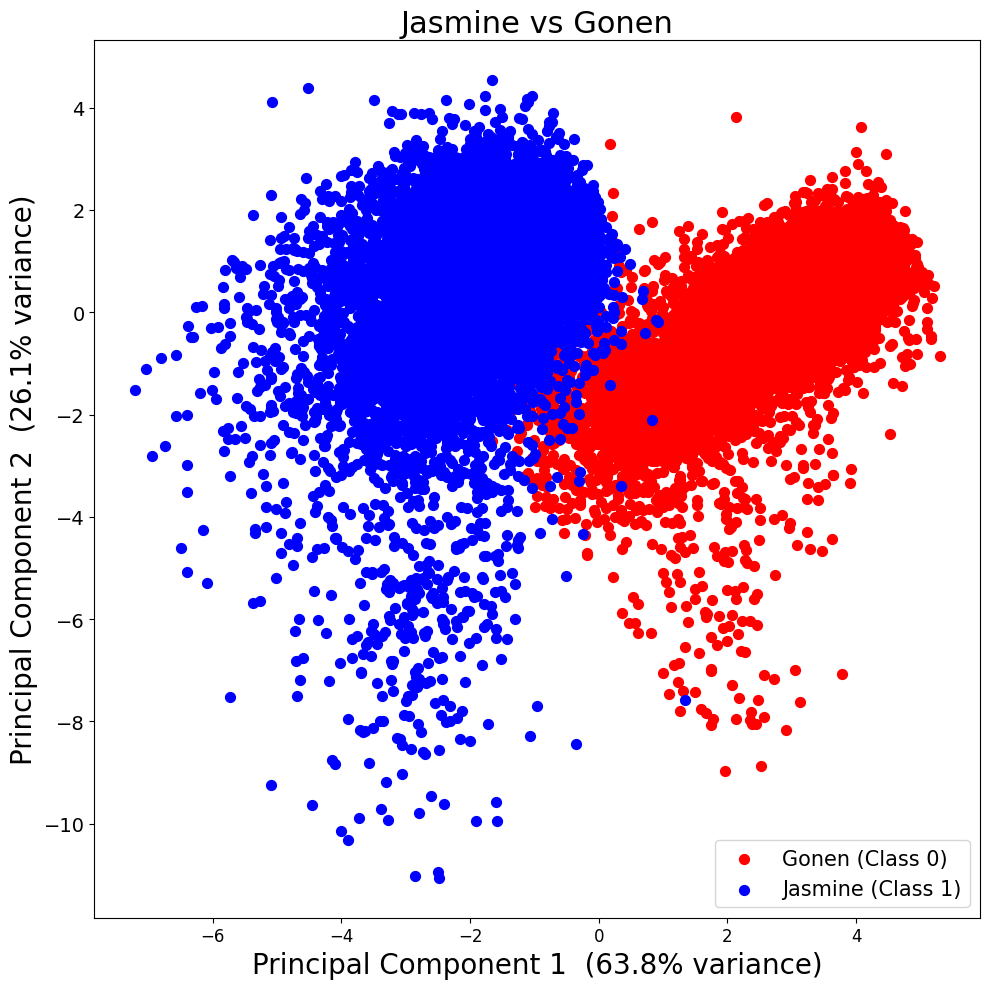

Plot saved as pca_rice.png


In [ ]:
# Making a big blank graph
plt.figure(figsize=(10, 10))

#labeling the graph and show the variance each PC keeps
plt.xlabel('Principal Component 1  ({:.1%} variance)'.format(pc1_var), fontsize=20)
plt.ylabel('Principal Component 2  ({:.1%} variance)'.format(pc2_var), fontsize=20)

#title
plt.title('Jasmine vs Gonen', fontsize=22)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)

colors = {
    0: ('r', 'Gonen (Class 0)'),
    1: ('b', 'Jasmine (Class 1)')
}

for label, (color, name) in colors.items():
    mask = df['Class'] == label
    plt.scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        c=color,
        s=50,
        label=name
    )
#legend
plt.legend(prop={'size': 15})
plt.tight_layout()
plt.savefig('pca_rice.png', dpi=150)
plt.show()

print('Plot saved as pca_rice.png')

For this dataset i used it to where each row is one rice grain and the goal is to tell if it the rice grain is Gonen (0) or Jasmine (1). I took the measurement columnns like the area, perimeter, and lengths then i scaled them so no single column wins just based off bigger numbers. Then i ran the PCA to shrink the data down to 2 columns so it can be plotted. PC1 keeps about 63.8% of the information and PC2 kept about 26.1% so together the 2D plot kept about 89.9% of the original information. On the PCA scatter plot the jasmine and gonen points seperate strongly which shows that the measurements contain clear patterns that help tell the two rice types apart.